In [3]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [4]:
# Load the dataset
#file_path = 'Data/Final/San_Jose___Jackson.csv'
file_path = 'Data/Weather/historical_weather_data_San_Jose_-_Jackson.csv'
data = pd.read_csv(file_path)

# Drop irrelevant columns
#cols_to_drop = ['latitude','longitude','city']
cols_to_drop = []
data.drop(cols_to_drop, axis=1, inplace=True)

# Check the first few rows to see the data structure
print(data.head())

# Define the columns to be used for the drought prediction model
cols = ['temperature_2m', 'relative_humidity_2m', 
        'wind_speed_10m', 'pressure_msl', 'precipitation', 'cloud_cover']
data = data[cols]

data.isnull().sum() 

data.fillna(data.mean(), inplace=True)


                  date  temperature_2m  relative_humidity_2m  wind_speed_10m  \
0  2014-01-01 07:00:00          10.149             50.235220        7.421590   
1  2014-01-01 08:00:00           8.999             52.524770        9.000000   
2  2014-01-01 09:00:00           8.149             53.450424        9.470120   
3  2014-01-01 10:00:00           7.449             54.046803        7.952660   
4  2014-01-01 11:00:00           6.599             55.019424        8.707238   

   pressure_msl  precipitation  cloud_cover                City  
0        1021.9            0.0         30.0  San Jose - Jackson  
1        1022.0            0.0         17.0  San Jose - Jackson  
2        1021.6            0.0          6.0  San Jose - Jackson  
3        1022.0            0.0          2.0  San Jose - Jackson  
4        1021.9            0.0          6.0  San Jose - Jackson  


In [5]:
data['temp_rolling_avg'] = data['temperature_2m'].rolling(window=7).mean()
data['precip_rolling_avg'] = data['precipitation'].rolling(window=7).mean()

data['precip_cumulative'] = data['precipitation'].cumsum()

data['drought'] = (data['precipitation'] < 5) & (data['temperature_2m'] > 35)  

# Drop any NaN values that may have been introduced by rolling averages
data.dropna(inplace=True)

In [6]:
scaler = MinMaxScaler()

# Scale the features
data_scaled = scaler.fit_transform(data[cols])

print(data_scaled[:5])

[[0.13755208 0.55361306 0.23908301 0.6904277  0.         0.05      ]
 [0.13442708 0.53977385 0.2059944  0.6904277  0.         0.        ]
 [0.13546875 0.52242229 0.20675036 0.69857434 0.         0.        ]
 [0.14276041 0.51485762 0.21328719 0.70672098 0.         0.        ]
 [0.23130208 0.39885327 0.18958861 0.71690428 0.         0.        ]]


In [7]:
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back])  # Create sequences of 'look_back' length
        y.append(data[i + look_back, -1])  # The last column (drought) is the target
    return np.array(X), np.array(y)

look_back = 30  # Use the last 30 days of data to predict the next day

# Create sequences for the features (X) and the target variable (y)
X, y = create_sequences(data_scaled, look_back)

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes
print(X_train.shape, y_train.shape)

(78878, 30, 6) (78878,)


In [8]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))  # Dropout for regularization
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1, activation='sigmoid'))  # Sigmoid for binary classification (drought/no drought)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy * 100:.2f}%")

Epoch 1/10


/Users/KumarVeena/Documents/Prathik/droughtprediction/drought/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2465/2465 ━━━━━━━━━━━━━━━━━━━━ 34s 13ms/step - accuracy: 0.4328 - loss: 0.4013 - val_accuracy: 0.4541 - val_loss: 0.3273
Epoch 2/10
2465/2465 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.4488 - loss: 0.3357 - val_accuracy: 0.4548 - val_loss: 0.3214
Epoch 3/10
2465/2465 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - accuracy: 0.4535 - loss: 0.3307 - val_accuracy: 0.4544 - val_loss: 0.3184
Epoch 4/10
2465/2465 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.4460 - loss: 0.3286 - val_accuracy: 0.4542 - val_loss: 0.3161
Epoch 5/10
2465/2465 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.4478 - loss: 0.3257 - val_accuracy: 0.4546 - val_loss: 0.3147
Epoch 6/10
2465/2465 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.4500 - loss: 0.3269 - val_accuracy: 0.4545 - val_loss: 0.3140
Epoch 7/10
2465/2465 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - accuracy: 0.4517 - loss: 0.3228 - val_accuracy: 0.4547 - val_loss: 0.3130
Epoch 8/10
2465/2465 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.4480 - loss: 0.32

In [9]:
# Ensure y_test is binary (0 or 1)
y_test_binary = (y_test > 0.5).astype(int)  # Convert continuous y_test to binary if needed

# Predict drought conditions on the test set
y_pred = model.predict(X_test)

# Convert the predictions to binary (drought or no drought)
y_pred_binary = (y_pred > 0.5).astype(int)

# Print the classification report
from sklearn.metrics import classification_report
print(classification_report(y_test_binary, y_pred_binary))



617/617 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
              precision    recall  f1-score   support

           0       0.92      0.91      0.92     11606
           1       0.87      0.89      0.88      8114

    accuracy                           0.90     19720
   macro avg       0.90      0.90      0.90     19720
weighted avg       0.90      0.90      0.90     19720



Last precipitation value: 0.0

Correlation of Weather Features with Drought Condition:
drought                 1.000000
temperature_2m          0.657913
wind_speed_10m          0.314435
precipitation          -0.053069
cloud_cover            -0.211180
pressure_msl           -0.256008
relative_humidity_2m   -0.534202
Name: drought, dtype: float64


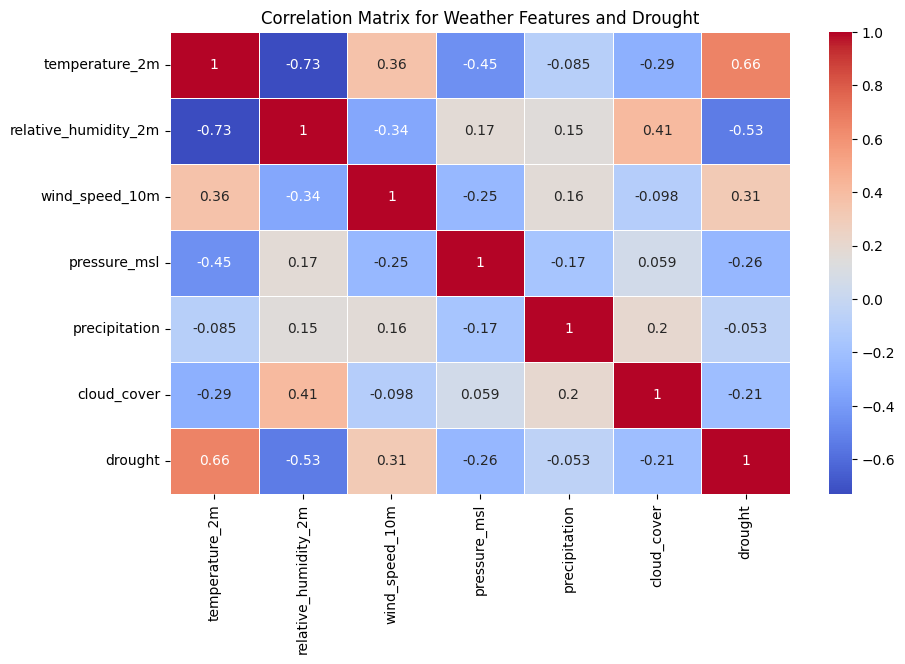


Predicted Drought Conditions for the Next 30 Days:
      Date  Predicted Drought
2025-04-13                  0
2025-04-14                  0
2025-04-15                  0
2025-04-16                  0
2025-04-17                  0
2025-04-18                  0
2025-04-19                  0
2025-04-20                  0
2025-04-21                  0
2025-04-22                  0
2025-04-23                  0
2025-04-24                  0
2025-04-25                  0
2025-04-26                  0
2025-04-27                  0
2025-04-28                  0
2025-04-29                  0
2025-04-30                  0
2025-05-01                  0
2025-05-02                  0
2025-05-03                  0
2025-05-04                  0
2025-05-05                  0
2025-05-06                  0
2025-05-07                  0
2025-05-08                  0
2025-05-09                  0
2025-05-10                  0
2025-05-11                  0
2025-05-12                  0


In [10]:

missing_features = [col for col in cols if col not in data.columns]
if missing_features:
    raise KeyError(f"Missing required columns: {missing_features}")

# Define drought condition (Assume based on precipitation threshold)
data['drought'] = ((data['precipitation'] < 0.2) & (data['temperature_2m'] > 25)).astype(int)

print("Last precipitation value:", data['precipitation'].iloc[-1])
# ===================== Correlation Matrix =========================== #
correlation_matrix = data[cols + ['drought']].corr()

# Display correlation with drought condition
print("\nCorrelation of Weather Features with Drought Condition:")
print(correlation_matrix['drought'].sort_values(ascending=False))

# Plot correlation matrix as heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix for Weather Features and Drought")
plt.show()

# ============================== Model is trained ==================#
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]


model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(train_data[cols], train_data['drought'])

# === Predict Future Drought Conditions ===
today = datetime.today()
future_dates = [(today + timedelta(days=i)).strftime('%Y-%m-%d') for i in range(1, 31)]

# Use last known values as reference for future predictions
latest_weather = data.iloc[-1][cols]
future_weather_data = pd.DataFrame([latest_weather] * 30, index=future_dates, columns=cols)

# Predict drought conditions for the next 30 days
y_pred_proba_future = model.predict_proba(future_weather_data)[:, 1]  # Probability output
y_pred_binary_future = (y_pred_proba_future > 0.5).astype(int)  # Convert to binary (0 or 1)

# Create a DataFrame for results
results_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Drought': y_pred_binary_future
})

# Print results in table format
print("\nPredicted Drought Conditions for the Next 30 Days:")
print(results_df.to_string(index=False))



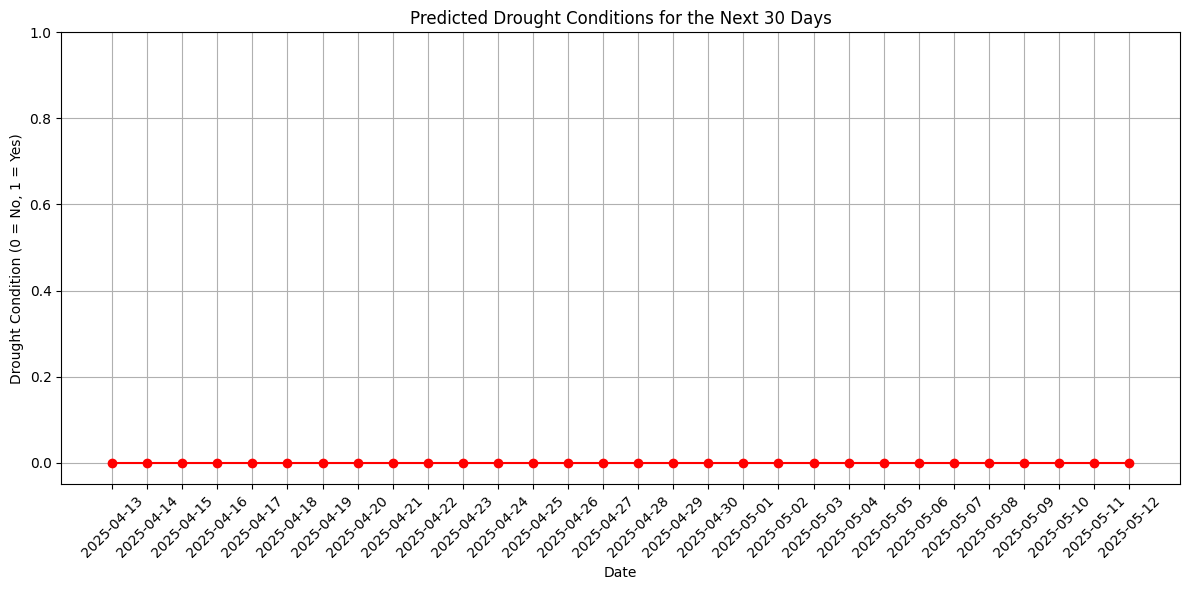

In [11]:
# === Plot Future Drought Predictions ===
plt.figure(figsize=(12, 6))
plt.plot(future_dates, y_pred_binary_future, label='Predicted Drought', color='r', marker='o')
plt.ylim(-0.05, 1)
# Customize the plot
plt.title('Predicted Drought Conditions for the Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Drought Condition (0 = No, 1 = Yes)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
